In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms

import numpy as np
from PIL import Image
import os
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Librerías cargadas")
print(f"🖥️  Dispositivo: {device}")

✅ Librerías cargadas
🖥️  Dispositivo: cuda


In [33]:
from google.colab import drive
drive.mount('/content/drive')

BASE             = '/content/drive/MyDrive/trazos'
PATH_IMAGENES    = os.path.join(BASE, 'imagenes_de_ejemplo')
PATH_MODELOS_V4  = os.path.join(BASE, 'modelos', 'fase3')

# Verificar que existen
for r in [PATH_IMAGENES, PATH_MODELOS_V4]:
    estado = "✅" if os.path.exists(r) else "❌ NO EXISTE"
    print(f"{estado} — {r}")

# Listar imágenes disponibles
imagenes = [f for f in sorted(os.listdir(PATH_IMAGENES))
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

print(f"\n📁 Imágenes encontradas en imagenes_de_ejemplo:")
for i, img in enumerate(imagenes):
    print(f"   {i+1}. {img}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ — /content/drive/MyDrive/trazos/imagenes_de_ejemplo
✅ — /content/drive/MyDrive/trazos/modelos/fase3

📁 Imágenes encontradas en imagenes_de_ejemplo:
   1. Estanteria 2.png
   2. Estanteria.png
   3. tuberia 2.png
   4. tuberia 3.png
   5. tuberia 4.png
   6. tuberia 5.png
   7. tuberia 6.png
   8. tuberia 7.png
   9. tuberia.png


In [34]:
class DobleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.bloque = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.bloque(x)


class UNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, features=[64, 128, 256, 512]):
        super().__init__()
        self.encoder    = nn.ModuleList()
        self.pool       = nn.MaxPool2d(2, 2)
        self.decoder    = nn.ModuleList()

        ch = in_ch
        for f in features:
            self.encoder.append(DobleConv(ch, f))
            ch = f

        self.bottleneck = DobleConv(features[-1], features[-1] * 2)

        for f in reversed(features):
            self.decoder.append(nn.ConvTranspose2d(f * 2, f, 2, stride=2))
            self.decoder.append(DobleConv(f * 2, f))

        self.final = nn.Conv2d(features[0], out_ch, 1)

    def forward(self, x):
        skips = []
        for enc in self.encoder:
            x = enc(x)
            skips.append(x)
            x = self.pool(x)

        x     = self.bottleneck(x)
        skips = skips[::-1]

        for i in range(0, len(self.decoder), 2):
            x    = self.decoder[i](x)
            skip = skips[i // 2]
            if x.shape != skip.shape:
                x = torch.nn.functional.interpolate(
                    x, size=skip.shape[2:],
                    mode='bilinear', align_corners=False
                )
            x = torch.cat([skip, x], dim=1)
            x = self.decoder[i + 1](x)

        return torch.sigmoid(self.final(x))


modelo = UNet().to(device)
print("✅ Arquitectura U-Net definida")

✅ Arquitectura U-Net definida


In [35]:
ruta_pesos = os.path.join(PATH_MODELOS_V4, 'v4_unet_tuberias_best_iou.pth')

if os.path.exists(ruta_pesos):
    modelo.load_state_dict(
        torch.load(ruta_pesos, map_location=device)
    )
    modelo.eval()
    print(f"✅ Pesos v4 cargados correctamente")
    print(f"   Ruta: {ruta_pesos}")
else:
    print(f"❌ No se encontró el archivo de pesos")
    print(f"   Buscado en: {ruta_pesos}")

✅ Pesos v4 cargados correctamente
   Ruta: /content/drive/MyDrive/trazos/modelos/fase3/v4_unet_tuberias_best_iou.pth


In [36]:
def inferencia(ruta_imagen, modelo, threshold=0.5, img_size=256):
    """
    Recibe ruta de imagen real y genera overlay estructural.
    threshold: sensibilidad de detección (0.3 más sensible, 0.7 más estricto)
    """
    modelo.eval()

    # Cargar imagen
    nombre = os.path.basename(ruta_imagen)
    img    = Image.open(ruta_imagen).convert('RGB')
    w_orig, h_orig = img.size

    # Preprocesar
    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])
    img_tensor = transform(img).unsqueeze(0).to(device)

    # Inferencia
    with torch.no_grad():
        pred = modelo(img_tensor).squeeze().cpu().numpy()

    pred_bin = (pred > threshold).astype(np.float32)
    img_np   = np.array(img.resize((img_size, img_size))) / 255.0

    # Overlay verde
    overlay = img_np.copy()
    overlay[pred_bin == 1] = [0, 1, 0]

    # Visualizar
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    fig.suptitle(f'as_built v4 — {nombre}  |  threshold={threshold}',
                 fontsize=12)

    axes[0].imshow(img_np)
    axes[0].set_title('Imagen original')
    axes[0].axis('off')

    axes[1].imshow(pred_bin, cmap='gray')
    axes[1].set_title('Overlay predicho')
    axes[1].axis('off')

    axes[2].imshow(overlay)
    axes[2].set_title('Overlay superpuesto')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    # Info
    pixeles_estructura = int(pred_bin.sum())
    porcentaje         = pixeles_estructura / (img_size * img_size) * 100
    print(f"   Píxeles detectados como estructura : {pixeles_estructura:,}")
    print(f"   Porcentaje de la imagen            : {porcentaje:.1f}%")
    print()

    return pred_bin


print("✅ Función de inferencia lista")

✅ Función de inferencia lista


✅ Imagen encontrada: tuberia.png


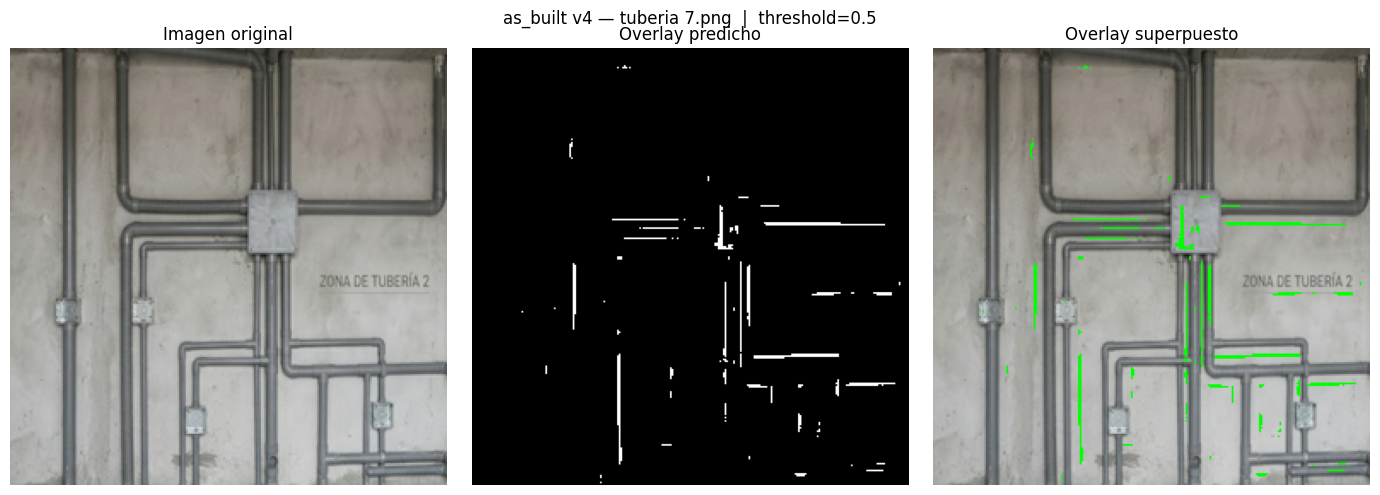

   Píxeles detectados como estructura : 1,064
   Porcentaje de la imagen            : 1.6%



In [37]:
# Ruta de tu imagen
ruta = os.path.join(PATH_IMAGENES, 'tuberia 7.png')

# Verificar que existe
if os.path.exists(ruta):
    print(f"✅ Imagen encontrada: tuberia.png")
    resultado = inferencia(ruta, modelo, threshold=0.5)
else:
    print(f"❌ No se encontró: {ruta}")
    print(f"   Archivos disponibles:")
    for f in imagenes:
        print(f"   → {f}")

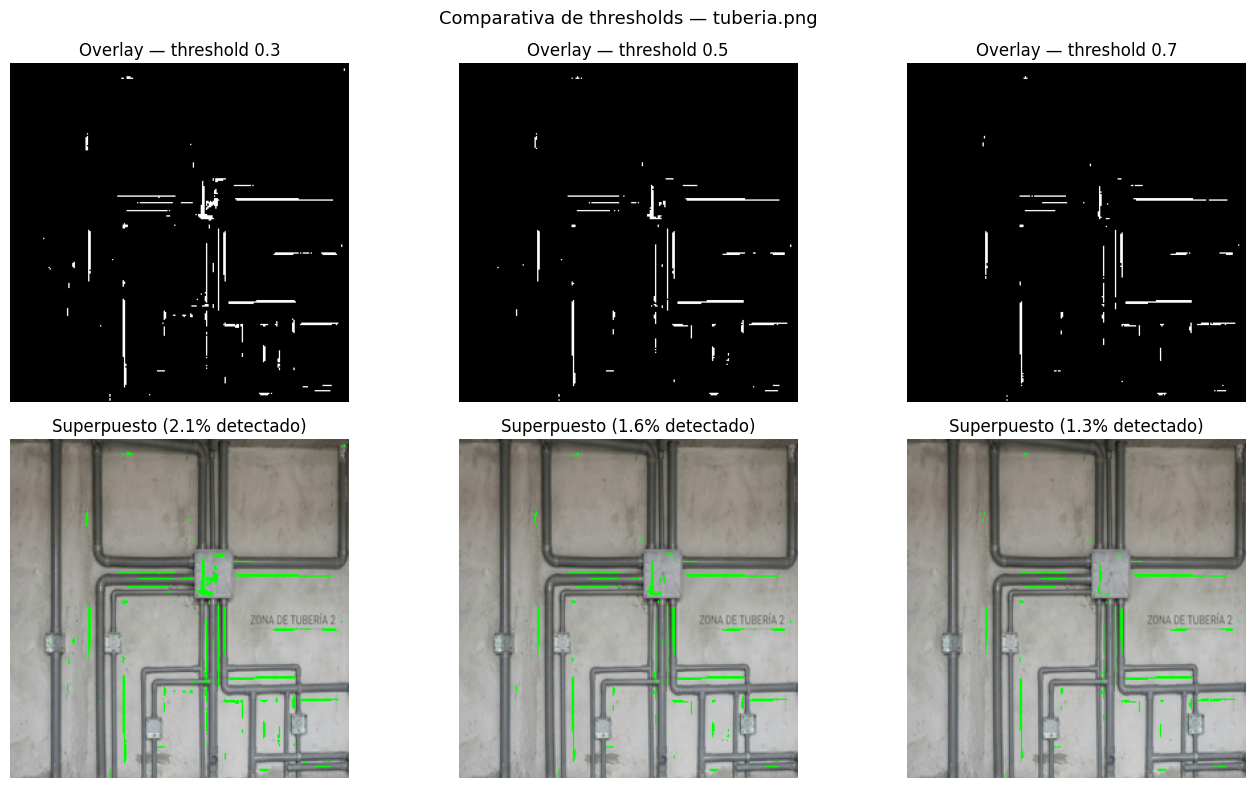

💡 El threshold ideal es el que detecta la estructura
   sin demasiado ruido ni demasiadas líneas perdidas


In [38]:
ruta = os.path.join(PATH_IMAGENES, 'tuberia 7.png')

thresholds = [0.3, 0.5, 0.7]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Comparativa de thresholds — tuberia.png', fontsize=13)

img     = Image.open(ruta).convert('RGB')
img_np  = np.array(img.resize((256, 256))) / 255.0
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])
img_tensor = transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    pred = modelo(img_tensor).squeeze().cpu().numpy()

for col, th in enumerate(thresholds):
    pred_bin = (pred > th).astype(np.float32)
    overlay  = img_np.copy()
    overlay[pred_bin == 1] = [0, 1, 0]

    axes[0][col].imshow(pred_bin, cmap='gray')
    axes[0][col].set_title(f'Overlay — threshold {th}')
    axes[0][col].axis('off')

    axes[1][col].imshow(overlay)
    pct = pred_bin.sum() / (256*256) * 100
    axes[1][col].set_title(f'Superpuesto ({pct:.1f}% detectado)')
    axes[1][col].axis('off')

plt.tight_layout()
plt.show()
print("💡 El threshold ideal es el que detecta la estructura")
print("   sin demasiado ruido ni demasiadas líneas perdidas")

In [40]:
THRESHOLD_ELEGIDO = 0.5  # ← cambia según lo que viste en celda 7

print(f"🔍 Probando todas las imágenes con threshold={THRESHOLD_ELEGIDO}")
print()

for nombre_img in imagenes:
    ruta = os.path.join(PATH_IMAGENES, nombre_img)
    print(f"── {nombre_img} ──")
    resultado = inferencia(ruta, modelo, threshold=THRESHOLD_ELEGIDO)

Output hidden; open in https://colab.research.google.com to view.